# 9. Inventory Optimization

With a reliable demand forecasting model established, the next step is to convert demand predictions into actionable inventory decisions.

The merged dataset **Final_Demand** contains actual demand from the training period and forecasted demand from the testing period, providing a complete annual demand view for each SKU. Using this demand baseline, inventory optimization techniques are applied to improve stock availability, reduce carrying costs, and support data-driven replenishment decisions.

The first step in inventory optimization is **ABC Analysis**, which identifies high-value and low-value products based on their contribution to overall inventory consumption.

---


## 9.1 ABC Analysis

### 📌 Business Context & Objective

In retail inventory management, a small percentage of products typically account for the majority of inventory investment. Therefore, treating all SKUs with the same inventory policy often leads to inefficient resource allocation.

ABC Analysis is used to classify products based on their contribution to total inventory value using the Pareto Principle.

The classification is based on **Annual Consumption Value (ACV)**:

$$
\text{Annual Consumption Value}
=
\text{Annual Demand}
\times
\text{Unit Cost}
$$

Products contributing the highest inventory value are assigned higher priority for monitoring and replenishment decisions.

### Classification Criteria

- **Category A:** Top 80% of cumulative inventory value
- **Category B:** Next 15% of cumulative inventory value
- **Category C:** Remaining 5% of cumulative inventory value

This classification forms the foundation for differentiated inventory control strategies, service level targets, safety stock policies, and replenishment planning.

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [2]:
Final_Demand = pd.read_csv('Final_Demand.csv')

In [3]:
# ----------------------------------------------------------
# Annual Demand Per SKU
# ----------------------------------------------------------

annual_demand = (
    Final_Demand
    .groupby("SKU")["Forecasted_Demand"]
    .sum()
    .reset_index()
)

annual_demand.rename(
    columns={"Forecasted_Demand": "Annual_Demand"},
    inplace=True
)

annual_demand

,SKU,Annual_Demand
0,Product_0001,60298.031755
1,Product_0002,488346.354856
2,Product_0003,17695.822994
3,Product_0004,20505.145881
4,Product_0005,2587.732354
...,...,...
2112,Product_2168,4204.774769
2113,Product_2169,1888.468089
2114,Product_2170,230.254156
2115,Product_2171,267.752989


In [4]:
Inventory =  pd.read_csv('Inventory_Master_FINAL.csv')

Inventory

,SKU,Product_Category,Unit_Cost,Lead_Time_Days,Ordering_Cost,Holding_Cost_Per_Unit_Year
0,Product_1359,Category_019,0.61,4,2951,375.96
1,Product_0083,Category_019,1.15,14,2644,435.32
2,Product_1248,Category_019,1.10,7,1206,437.39
3,Product_1295,Category_019,2.00,4,2220,430.33
4,Product_1432,Category_019,2.36,2,4024,324.65
...,...,...,...,...,...,...
2112,Product_0467,Category_013,260.18,11,5025,1.05
2113,Product_1944,Category_001,256.91,3,5745,0.80
2114,Product_0527,Category_022,856.17,4,3722,1.44
2115,Product_1698,Category_021,256.91,12,1737,1.34


In [5]:
# ----------------------------------------------------------
# Merge Unit Cost
# ----------------------------------------------------------

abc_df = annual_demand.merge(
    Inventory[
        ["SKU", "Unit_Cost"]
    ],
    on="SKU",
    how="left"
)

# ----------------------------------------------------------
# Annual Consumption Value
# ----------------------------------------------------------

abc_df["Annual_Consumption_Value"] = (
    abc_df["Annual_Demand"]
    * abc_df["Unit_Cost"]
)

# ----------------------------------------------------------
# Sort by Consumption Value
# ----------------------------------------------------------

abc_df = abc_df.sort_values(
    by="Annual_Consumption_Value",
    ascending=False
)

# ----------------------------------------------------------
# Cumulative Percentage
# ----------------------------------------------------------

total_value = abc_df["Annual_Consumption_Value"].sum()

abc_df["Cumulative_Value"] = (
    abc_df["Annual_Consumption_Value"].cumsum()
)

abc_df["Cumulative_Percentage"] = (
    abc_df["Cumulative_Value"]
    / total_value
) * 100

# ----------------------------------------------------------
# ABC Classification
# ----------------------------------------------------------

def classify_abc(x):

    if x <= 80:
        return "A"

    elif x <= 95:
        return "B"

    else:
        return "C"

abc_df["ABC_Category"] = (
    abc_df["Cumulative_Percentage"]
    .apply(classify_abc)
)

# ----------------------------------------------------------
# Results
# ----------------------------------------------------------

print("="*60)
print("ABC CATEGORY DISTRIBUTION")
print("="*60)

print(
    abc_df["ABC_Category"]
    .value_counts()
    .sort_index()
)

abc_df

ABC CATEGORY DISTRIBUTION
ABC_Category
A     505
B     278
C    1334
Name: count, dtype: int64


,SKU,Annual_Demand,Unit_Cost,Annual_Consumption_Value,Cumulative_Value,Cumulative_Percentage,ABC_Category
1314,Product_1359,5.613101e+07,0.61,3.423992e+07,3.423992e+07,0.214897,A
82,Product_0083,2.963875e+07,1.15,3.408456e+07,6.832447e+07,0.428819,A
1405,Product_1451,1.174217e+07,2.89,3.393486e+07,1.022593e+08,0.641801,A
1433,Product_1480,1.161122e+07,2.92,3.390476e+07,1.361641e+08,0.854595,A
1204,Product_1248,3.080933e+07,1.10,3.389026e+07,1.700544e+08,1.067297,A
...,...,...,...,...,...,...,...
580,Product_0592,0.000000e+00,256.91,0.000000e+00,1.593318e+10,100.000000,C
1583,Product_1631,0.000000e+00,256.91,0.000000e+00,1.593318e+10,100.000000,C
922,Product_0948,0.000000e+00,256.91,0.000000e+00,1.593318e+10,100.000000,C
1387,Product_1433,0.000000e+00,256.91,0.000000e+00,1.593318e+10,100.000000,C


## 9.1.1 ABC SUMMARY TABLE

In [6]:
abc_summary = (
    abc_df.groupby("ABC_Category")
    .agg(
        SKU_Count=("SKU", "count"),
        Total_ACV=("Annual_Consumption_Value", "sum")
    )
    .reset_index()
)

# SKU Share %
abc_summary["SKU_Share_Pct"] = (
    abc_summary["SKU_Count"]
    / abc_summary["SKU_Count"].sum()
) * 100

# Value Share %
abc_summary["Value_Share_Pct"] = (
    abc_summary["Total_ACV"]
    / abc_summary["Total_ACV"].sum()
) * 100

abc_summary

,ABC_Category,SKU_Count,Total_ACV,SKU_Share_Pct,Value_Share_Pct
0,A,505,1.274626e+10,23.854511,79.998212
1,B,278,2.389730e+09,13.131790,14.998452
2,C,1334,7.971904e+08,63.013699,5.003336


## 9.1.2 Bar Charts (SKU Share vs Inventory Value Contribution)

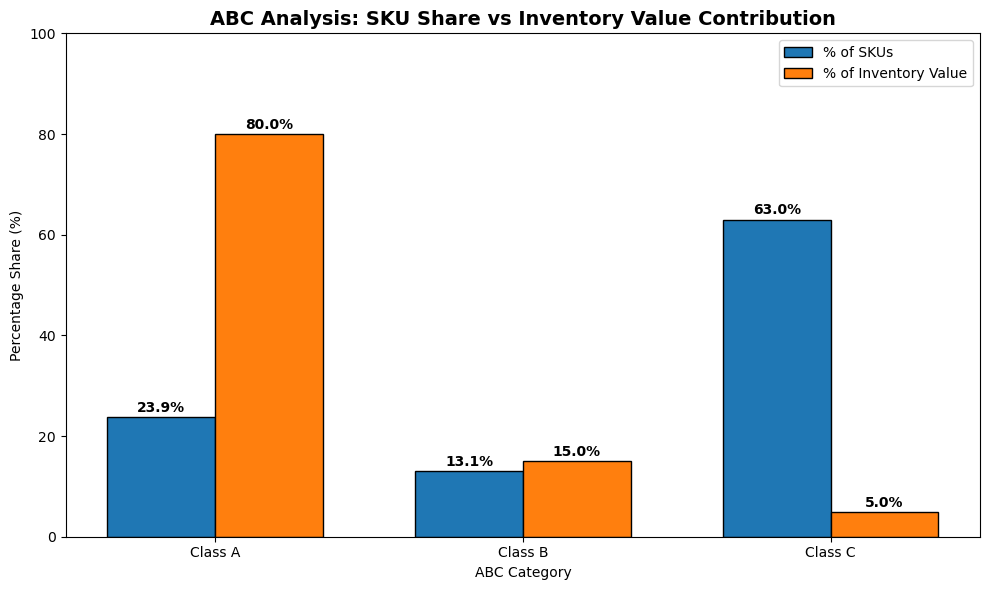

In [7]:
# ----------------------------------------------------------
# Data
# ----------------------------------------------------------

classes = ["Class A", "Class B", "Class C"]

sku_shares = abc_summary["SKU_Share_Pct"].values
value_shares = abc_summary["Value_Share_Pct"].values

x = np.arange(len(classes))
width = 0.35

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(10,6))

bars1 = ax.bar(
    x - width/2,
    sku_shares,
    width,
    label="% of SKUs",
    edgecolor="black"
)

bars2 = ax.bar(
    x + width/2,
    value_shares,
    width,
    label="% of Inventory Value",
    edgecolor="black"
)

# ----------------------------------------------------------
# Labels
# ----------------------------------------------------------

for bar in bars1:
    h = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 1,
        f"{h:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

for bar in bars2:
    h = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 1,
        f"{h:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------

ax.set_title(
    "ABC Analysis: SKU Share vs Inventory Value Contribution",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("ABC Category")
ax.set_ylabel("Percentage Share (%)")

ax.set_xticks(x)
ax.set_xticklabels(classes)

ax.set_ylim(0,100)

ax.legend()

plt.tight_layout()
plt.show()

## 9.1.3 PARETO CHART OF ANNUAL CONSUMPTION VALUE

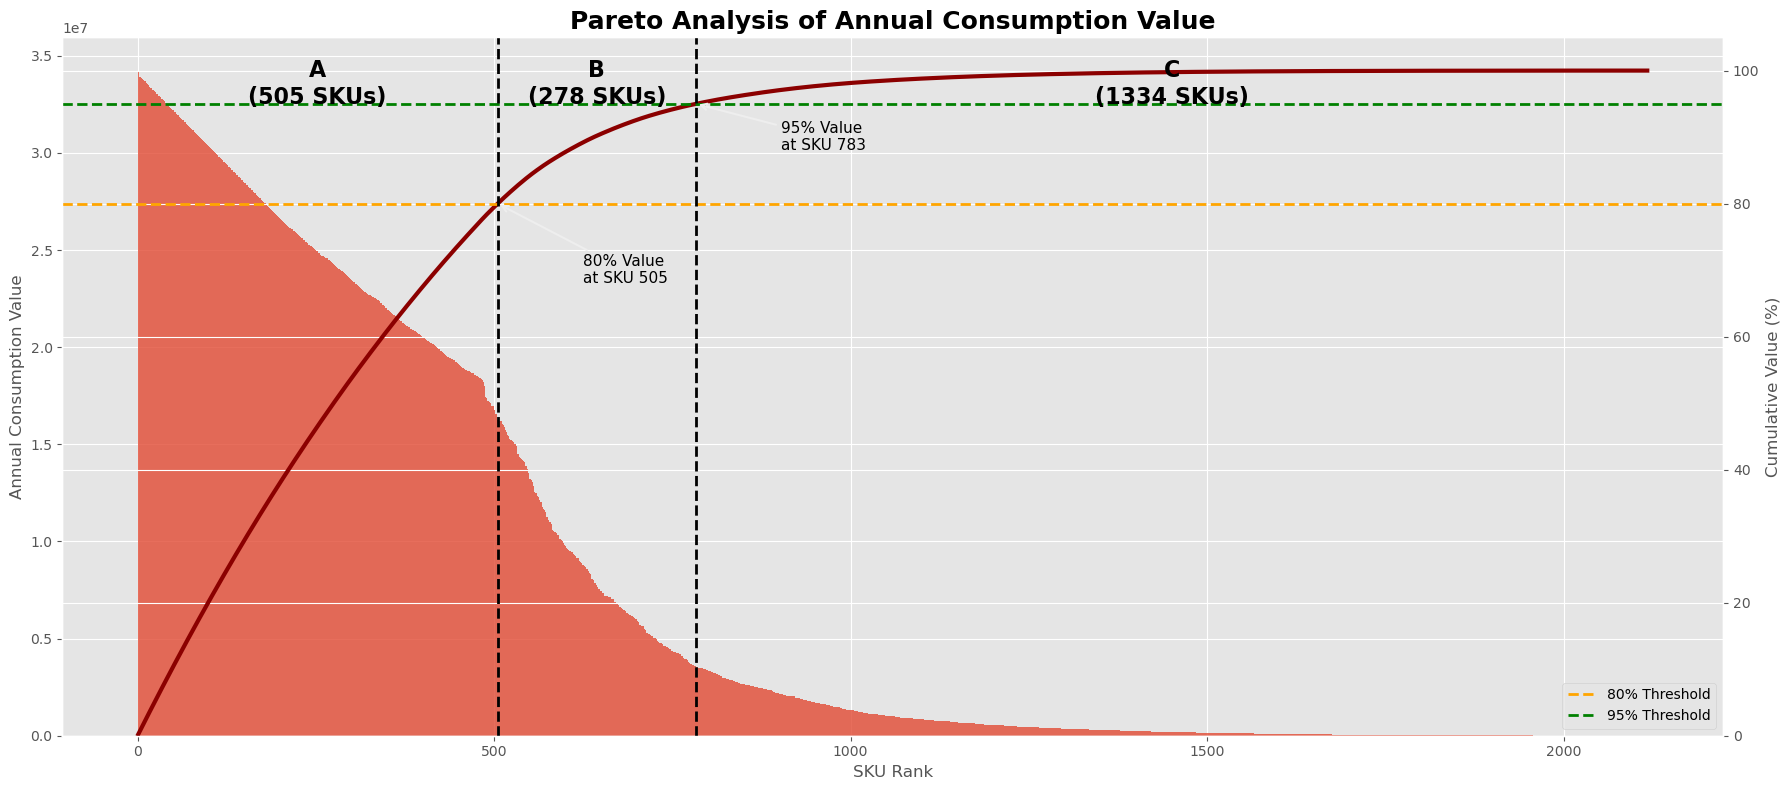

In [8]:
# ==========================================================
# PREPARE DATA
# ==========================================================

pareto_df = (
    abc_df
    .sort_values(
        by="Annual_Consumption_Value",
        ascending=False
    )
    .reset_index(drop=True)
)

pareto_df["SKU_Rank"] = np.arange(
    1,
    len(pareto_df) + 1
)

pareto_df["Cumulative_Percentage"] = (
    pareto_df["Annual_Consumption_Value"]
    .cumsum()
    /
    pareto_df["Annual_Consumption_Value"]
    .sum()
) * 100

# ==========================================================
# ABC BOUNDARIES
# ==========================================================

A_end = (
    pareto_df["ABC_Category"] == "A"
).sum()

B_end = (
    pareto_df["ABC_Category"]
    .isin(["A","B"])
).sum()

total_skus = len(pareto_df)

# ==========================================================
# FIGURE
# ==========================================================

plt.style.use("ggplot")

fig, ax1 = plt.subplots(
    figsize=(18,8)
)

# ==========================================================
# BARS
# ==========================================================

ax1.bar(
    pareto_df["SKU_Rank"],
    pareto_df["Annual_Consumption_Value"],
    width=1,
    alpha=0.8
)

ax1.set_xlabel(
    "SKU Rank",
    fontsize=12
)

ax1.set_ylabel(
    "Annual Consumption Value",
    fontsize=12
)

# ==========================================================
# PARETO CURVE
# ==========================================================

ax2 = ax1.twinx()

ax2.plot(
    pareto_df["SKU_Rank"],
    pareto_df["Cumulative_Percentage"],
    linewidth=3,
    color="darkred"
)

ax2.set_ylabel(
    "Cumulative Value (%)",
    fontsize=12
)

ax2.set_ylim(
    0,
    105
)

# ==========================================================
# THRESHOLDS
# ==========================================================

ax2.axhline(
    y=80,
    linestyle="--",
    linewidth=2,
    color="orange",
    label="80% Threshold"
)

ax2.axhline(
    y=95,
    linestyle="--",
    linewidth=2,
    color="green",
    label="95% Threshold"
)

# ==========================================================
# CATEGORY BOUNDARIES
# ==========================================================

ax2.axvline(
    x=A_end,
    linestyle="--",
    linewidth=2,
    color="black"
)

ax2.axvline(
    x=B_end,
    linestyle="--",
    linewidth=2,
    color="black"
)

# ==========================================================
# CATEGORY LABELS
# ==========================================================

ax2.text(
    A_end/2,
    98,
    f"A\n({A_end} SKUs)",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax2.text(
    (A_end+B_end)/2,
    98,
    f"B\n({B_end-A_end} SKUs)",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax2.text(
    (B_end+total_skus)/2,
    98,
    f"C\n({total_skus-B_end} SKUs)",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

# ==========================================================
# ANNOTATIONS
# ==========================================================

ax2.annotate(
    f"80% Value\nat SKU {A_end}",
    xy=(A_end,80),
    xytext=(A_end+120,68),
    arrowprops=dict(
        arrowstyle="->",
        lw=1.5
    ),
    fontsize=11
)

ax2.annotate(
    f"95% Value\nat SKU {B_end}",
    xy=(B_end,95),
    xytext=(B_end+120,88),
    arrowprops=dict(
        arrowstyle="->",
        lw=1.5
    ),
    fontsize=11
)

# ==========================================================
# TITLE
# ==========================================================

plt.title(
    "Pareto Analysis of Annual Consumption Value",
    fontsize=18,
    fontweight="bold"
)

ax2.legend(
    loc="lower right"
)

plt.tight_layout()
plt.show()

### Pareto Analysis Results

A Pareto chart was constructed using Annual Consumption Value (ACV) to visualize the cumulative contribution of SKUs to total inventory value.

The chart confirms the Pareto principle, where a relatively small proportion of SKUs contributes the majority of inventory investment. Based on cumulative value contribution:

- Category A includes SKUs contributing to the first 80% of inventory value.
- Category B includes SKUs contributing to the next 15%.
- Category C includes the remaining low-value SKUs.

The results support differentiated inventory control policies and resource allocation strategies.

In [9]:
# ==========================================================
# SAVE FINAL ABC ANALYSIS DATASET
# ==========================================================

ABC_Analysis = abc_df[
    [
        "SKU",
        "Annual_Demand",
        "Unit_Cost",
        "Annual_Consumption_Value",
        "ABC_Category"
    ]
].copy()

ABC_Analysis.to_csv(
    "ABC_Analysis.csv",
    index=False
)

print("ABC_Analysis.csv saved successfully.")
print("Shape :", ABC_Analysis.shape)

ABC_Analysis.csv saved successfully.
Shape : (2117, 5)


## 9.2 Safety Stock Calculation

### Business Context & Objective

In retail supply chain operations, actual demand rarely matches forecasted demand exactly. Additionally, supplier lead times may vary due to transportation delays, supplier reliability issues, or operational disruptions. These uncertainties can result in stockouts, lost sales, and reduced customer service levels.

To mitigate these risks, organizations maintain **Safety Stock**, which acts as a protective inventory buffer against unexpected demand fluctuations during replenishment lead time.

The objective of this analysis is to determine SKU-level safety stock requirements using forecasted demand variability and lead-time information while aligning inventory investment with ABC inventory priorities.

---

### Data Used

The following datasets were utilized:

- **Final_Demand.csv** → Forecasted demand for each SKU
- **ABC_Analysis.csv** → ABC inventory classification
- **Supplier_Data_FINAL.csv** → Lead time and supplier information

For each SKU, the following parameters were calculated:

- Average Daily Demand
- Demand Standard Deviation
- Lead Time (Days)
- ABC Category

---

In [10]:
# ==========================================================
# DEMAND VARIABILITY BY SKU
# ==========================================================

demand_stats = (
    Final_Demand.groupby("SKU")
    .agg(
        Avg_Daily_Demand=("Forecasted_Demand", "mean"),
        Demand_Std_Dev=("Forecasted_Demand", "std")
    )
    .reset_index()
)

demand_stats.head()

,SKU,Avg_Daily_Demand,Demand_Std_Dev
0,Product_0001,621.629193,987.643315
1,Product_0002,8567.479910,15110.421124
2,Product_0003,280.886079,235.346937
3,Product_0004,310.684028,418.919852
4,Product_0005,215.644363,258.871544


In [11]:
Supplier_Data = pd.read_csv('Supplier_Data_FINAL.csv')

Supplier_Data

,Supplier_ID,SKU,Lead_Time_Days,Supplier_Reliability,MOQ
0,SUP_0001,Product_1359,4,99.00,9637
1,SUP_0002,Product_0083,14,67.54,9336
2,SUP_0003,Product_1248,7,79.29,9755
3,SUP_0004,Product_1295,4,79.42,5564
4,SUP_0005,Product_1432,2,59.21,3877
...,...,...,...,...,...
2112,SUP_2113,Product_0467,11,96.64,15
2113,SUP_2114,Product_1944,3,54.08,15
2114,SUP_2115,Product_0527,4,51.98,50
2115,SUP_2116,Product_1698,12,87.11,15


In [12]:
# ==========================================================
# SAFETY STOCK MASTER DATASET
# ==========================================================

safety_stock_df = (
    ABC_Analysis
    .merge(
        demand_stats,
        on="SKU",
        how="left"
    )
    .merge(
        Supplier_Data,
        on="SKU",
        how="left"
    )
)

safety_stock_df.head()

,SKU,Annual_Demand,Unit_Cost,Annual_Consumption_Value,ABC_Category,Avg_Daily_Demand,Demand_Std_Dev,Supplier_ID,Lead_Time_Days,Supplier_Reliability,MOQ
0,Product_1359,5.613101e+07,0.61,3.423992e+07,A,21951.900077,65188.054362,SUP_0001,4,99.00,9637
1,Product_0083,2.963875e+07,1.15,3.408456e+07,A,81425.128498,219971.775068,SUP_0002,14,67.54,9336
2,Product_1451,1.174217e+07,2.89,3.393486e+07,A,18092.705046,28886.460936,SUP_0009,14,41.25,11638
3,Product_1480,1.161122e+07,2.92,3.390476e+07,A,41174.537083,161184.023699,SUP_0014,12,44.27,4057
4,Product_1248,3.080933e+07,1.10,3.389026e+07,A,29092.850967,76717.361394,SUP_0003,7,79.29,9755


---
### Service Level Policy

Different service levels were assigned based on ABC classification:

| ABC Category | Service Level | Z-Value |
|-------------|--------------|---------|
| A | 99% | 2.33 |
| B | 95% | 1.65 |
| C | 90% | 1.28 |

This approach ensures that high-value Category A products receive stronger stockout protection compared to lower-priority Category C products.

---

In [13]:
# ==========================================================
# SERVICE LEVEL MAPPING
# ==========================================================

service_levels = {
    "A": 2.33,
    "B": 1.65,
    "C": 1.28
}

safety_stock_df["Z_Value"] = (
    safety_stock_df["ABC_Category"]
    .map(service_levels)
)

---

### Safety Stock Formula

Safety stock was calculated using the standard inventory management model:

$$
Safety\ Stock = Z \times \sigma_d \times \sqrt{LT}
$$

Where:

- $Z$ = Service level factor
- $\sigma_d$ = Standard deviation of demand
- $LT$ = Lead time (days)

---

In [14]:
# ==========================================================
# SAFETY STOCK CALCULATION
# ==========================================================

safety_stock_df["Safety_Stock"] = np.ceil(
    safety_stock_df["Z_Value"]
    * safety_stock_df["Demand_Std_Dev"]
    * np.sqrt(safety_stock_df["Lead_Time_Days"])
)

safety_stock_df["Safety_Stock"] = (
    safety_stock_df["Safety_Stock"]
    .fillna(0)
)

safety_stock_df.head()

,SKU,Annual_Demand,Unit_Cost,Annual_Consumption_Value,ABC_Category,Avg_Daily_Demand,Demand_Std_Dev,Supplier_ID,Lead_Time_Days,Supplier_Reliability,MOQ,Z_Value,Safety_Stock
0,Product_1359,5.613101e+07,0.61,3.423992e+07,A,21951.900077,65188.054362,SUP_0001,4,99.00,9637,2.33,303777.0
1,Product_0083,2.963875e+07,1.15,3.408456e+07,A,81425.128498,219971.775068,SUP_0002,14,67.54,9336,2.33,1917728.0
2,Product_1451,1.174217e+07,2.89,3.393486e+07,A,18092.705046,28886.460936,SUP_0009,14,41.25,11638,2.33,251834.0
3,Product_1480,1.161122e+07,2.92,3.390476e+07,A,41174.537083,161184.023699,SUP_0014,12,44.27,4057,2.33,1300974.0
4,Product_1248,3.080933e+07,1.10,3.389026e+07,A,29092.850967,76717.361394,SUP_0003,7,79.29,9755,2.33,472932.0


### Safety Stock by ABC Category

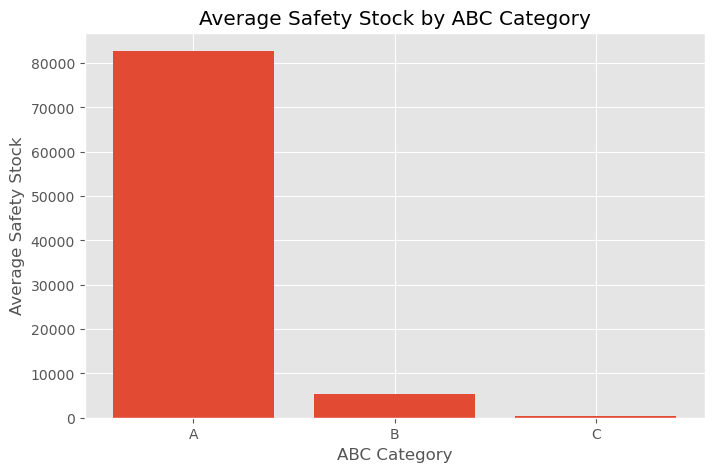

In [15]:
ss_summary = (
    safety_stock_df
    .groupby("ABC_Category")
    .agg(
        Avg_Safety_Stock=("Safety_Stock","mean")
    )
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.bar(
    ss_summary["ABC_Category"],
    ss_summary["Avg_Safety_Stock"]
)

plt.xlabel("ABC Category")
plt.ylabel("Average Safety Stock")
plt.title("Average Safety Stock by ABC Category")

plt.show()

### Top 20 Safety Stock SKUs

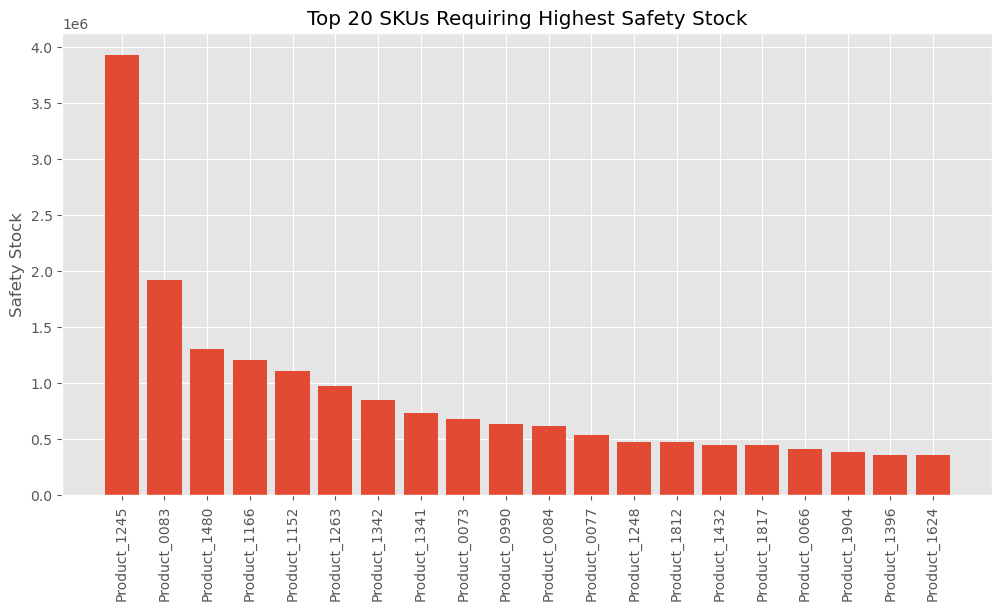

In [16]:
top20 = (
    safety_stock_df
    .sort_values(
        "Safety_Stock",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,6))

plt.bar(
    top20["SKU"],
    top20["Safety_Stock"]
)

plt.xticks(rotation=90)

plt.title(
    "Top 20 SKUs Requiring Highest Safety Stock"
)

plt.ylabel("Safety Stock")

plt.show()

---

### Business Interpretation

The calculated safety stock represents the minimum inventory buffer required to maintain the desired service level during supplier lead time.

- Higher demand variability results in larger safety stock requirements.
- Longer lead times increase inventory risk and therefore increase safety stock.
- Category A products maintain the highest inventory protection due to their significant contribution to overall inventory value.
- 31 SKUs exhibited insufficient demand variability observations. For such cases, demand standard deviation was assumed to be zero, resulting in minimum safety stock requirements.

The resulting safety stock values serve as a critical input for subsequent **Reorder Point (ROP)** and **Inventory Replenishment Policy** calculations.

---

### Key Observation

The analysis indicates that safety stock requirements vary significantly across SKUs due to differences in demand variability, lead time, and service level targets. High-value Category A products generally maintain larger inventory buffers to minimize stockout risk, while Category C products operate with comparatively lower safety stock levels to reduce inventory carrying costs.

In [17]:
# ==========================================================
# SAVE SAFETY STOCK DATASET
# ==========================================================

Safety_Stock = safety_stock_df.copy()

Safety_Stock.to_csv(
    "Safety_Stock.csv",
    index=False
)

print("Safety_Stock.csv saved successfully.")

Safety_Stock.csv saved successfully.


## 9.3 Reorder Point Determination

### Business Context & Objective

While Safety Stock protects against uncertainty, organizations also need a trigger point that indicates when replenishment should be initiated. This trigger level is known as the **Reorder Point (ROP)**.

The Reorder Point represents the inventory level at which a new purchase order should be placed so that replenishment arrives before stock is depleted.

The objective of this analysis is to calculate SKU-level reorder points using forecasted demand, supplier lead times, and safety stock requirements.

---

### Reorder Point Formula

$$
ROP = (Average\ Daily\ Demand \times Lead\ Time) + Safety\ Stock
$$

Where:

- Average Daily Demand = Average forecasted daily demand of the SKU
- Lead Time = Supplier replenishment lead time (days)
- Safety Stock = Inventory buffer maintained against uncertainty

---

In [18]:
# ==========================================================
# REORDER POINT CALCULATION
# ==========================================================

ROP = Safety_Stock.copy()

ROP["Reorder_Point"] = np.ceil(
    (
        ROP["Avg_Daily_Demand"]
        * ROP["Lead_Time_Days"]
    )
    +
    ROP["Safety_Stock"]
)

ROP.head()

,SKU,Annual_Demand,Unit_Cost,Annual_Consumption_Value,ABC_Category,Avg_Daily_Demand,Demand_Std_Dev,Supplier_ID,Lead_Time_Days,Supplier_Reliability,MOQ,Z_Value,Safety_Stock,Reorder_Point
0,Product_1359,5.613101e+07,0.61,3.423992e+07,A,21951.900077,65188.054362,SUP_0001,4,99.00,9637,2.33,303777.0,391585.0
1,Product_0083,2.963875e+07,1.15,3.408456e+07,A,81425.128498,219971.775068,SUP_0002,14,67.54,9336,2.33,1917728.0,3057680.0
2,Product_1451,1.174217e+07,2.89,3.393486e+07,A,18092.705046,28886.460936,SUP_0009,14,41.25,11638,2.33,251834.0,505132.0
3,Product_1480,1.161122e+07,2.92,3.390476e+07,A,41174.537083,161184.023699,SUP_0014,12,44.27,4057,2.33,1300974.0,1795069.0
4,Product_1248,3.080933e+07,1.10,3.389026e+07,A,29092.850967,76717.361394,SUP_0003,7,79.29,9755,2.33,472932.0,676582.0


In [19]:
# ==========================================================
# ROP SUMMARY
# ==========================================================

print("="*60)
print("REORDER POINT SUMMARY")
print("="*60)

print("Average ROP :", round(ROP["Reorder_Point"].mean(),2))
print("Maximum ROP :", round(ROP["Reorder_Point"].max(),2))
print("Minimum ROP :", round(ROP["Reorder_Point"].min(),2))

REORDER POINT SUMMARY
Average ROP : 37670.36
Maximum ROP : 8032120.0
Minimum ROP : 0.0


### Average ROP by ABC Category

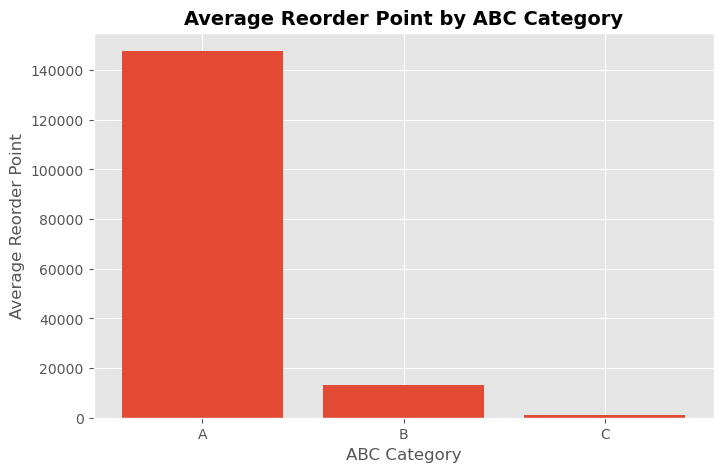

In [20]:
rop_summary = (
    ROP.groupby("ABC_Category")
    .agg(
        Avg_ROP=("Reorder_Point","mean")
    )
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.bar(
    rop_summary["ABC_Category"],
    rop_summary["Avg_ROP"]
)

plt.title(
    "Average Reorder Point by ABC Category",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("ABC Category")
plt.ylabel("Average Reorder Point")

plt.show()

---


### Business Interpretation

When on-hand inventory reaches the calculated reorder point, a replenishment order should be placed.

- Higher demand products generally have larger reorder points.
- Longer lead times increase reorder requirements.
- Safety stock provides additional protection against demand and supply uncertainty.

The resulting reorder point values form the basis of inventory replenishment decisions and service-level management.

In [21]:
# ==========================================================
# SAVE ROP DATASET
# ==========================================================

ROP.to_csv(
    "ROP_Analysis.csv",
    index=False
)

print("ROP_Analysis.csv saved successfully.")

ROP_Analysis.csv saved successfully.


## 9.4 Economic Order Quantity (EOQ)

### 📌 Business Context & Objective

While Safety Stock and Reorder Point determine **when to order**, organizations must also determine **how much to order** during each replenishment cycle.

Ordering too frequently increases procurement and administrative costs, whereas ordering large quantities increases inventory holding costs. Therefore, an optimal balance between ordering cost and carrying cost is required.

Economic Order Quantity (EOQ) is a classical inventory optimization technique that identifies the optimal order quantity that minimizes the total inventory cost.

---

### EOQ Concept

The Economic Order Quantity (EOQ) model determines the optimal order quantity that minimizes the total inventory cost by balancing ordering cost and inventory holding cost.

$$
EOQ = \sqrt{\frac{2DS}{H}}
$$

Where:

- **D** = Projected Annual Demand (Units)
- **S** = Ordering Cost per Order (₹)
- **H** = Holding Cost per Unit per Year (₹)

---

### Data Used

The following datasets were utilized:

- **ABC_Analysis.csv**
- **Inventory_Master_FINAL.csv**
- **ROP_Analysis.csv**

The following variables were used:

- Projected Annual Demand
- Ordering Cost
- Holding Cost Per Unit Per Year

---


In [22]:
# ==========================================================
# EOQ MASTER DATASET
# ==========================================================

EOQ = ROP.merge(
    Inventory,
    on="SKU",
    how="left"
)

EOQ.head()

,SKU,Annual_Demand,Unit_Cost_x,Annual_Consumption_Value,ABC_Category,Avg_Daily_Demand,Demand_Std_Dev,Supplier_ID,Lead_Time_Days_x,Supplier_Reliability,MOQ,Z_Value,Safety_Stock,Reorder_Point,Product_Category,Unit_Cost_y,Lead_Time_Days_y,Ordering_Cost,Holding_Cost_Per_Unit_Year
0,Product_1359,5.613101e+07,0.61,3.423992e+07,A,21951.900077,65188.054362,SUP_0001,4,99.00,9637,2.33,303777.0,391585.0,Category_019,0.61,4,2951,375.96
1,Product_0083,2.963875e+07,1.15,3.408456e+07,A,81425.128498,219971.775068,SUP_0002,14,67.54,9336,2.33,1917728.0,3057680.0,Category_019,1.15,14,2644,435.32
2,Product_1451,1.174217e+07,2.89,3.393486e+07,A,18092.705046,28886.460936,SUP_0009,14,41.25,11638,2.33,251834.0,505132.0,Category_019,2.89,14,1546,351.61
3,Product_1480,1.161122e+07,2.92,3.390476e+07,A,41174.537083,161184.023699,SUP_0014,12,44.27,4057,2.33,1300974.0,1795069.0,Category_019,2.92,12,3313,425.67
4,Product_1248,3.080933e+07,1.10,3.389026e+07,A,29092.850967,76717.361394,SUP_0003,7,79.29,9755,2.33,472932.0,676582.0,Category_019,1.10,7,1206,437.39


In [23]:
# ==========================================================
# ECONOMIC ORDER QUANTITY
# ==========================================================

EOQ["EOQ"] = np.ceil(
    np.sqrt(
        (
            2
            * EOQ["Annual_Demand"]
            * EOQ["Ordering_Cost"]
        )
        /
        EOQ["Holding_Cost_Per_Unit_Year"]
    )
)

EOQ.head(20)

,SKU,Annual_Demand,Unit_Cost_x,Annual_Consumption_Value,ABC_Category,Avg_Daily_Demand,Demand_Std_Dev,Supplier_ID,Lead_Time_Days_x,Supplier_Reliability,MOQ,Z_Value,Safety_Stock,Reorder_Point,Product_Category,Unit_Cost_y,Lead_Time_Days_y,Ordering_Cost,Holding_Cost_Per_Unit_Year,EOQ
0,Product_1359,5.613101e+07,0.61,3.423992e+07,A,21951.900077,65188.054362,SUP_0001,4,99.00,9637,2.33,303777.0,391585.0,Category_019,0.61,4,2951,375.96,29685.0
1,Product_0083,2.963875e+07,1.15,3.408456e+07,A,81425.128498,219971.775068,SUP_0002,14,67.54,9336,2.33,1917728.0,3057680.0,Category_019,1.15,14,2644,435.32,18975.0
2,Product_1451,1.174217e+07,2.89,3.393486e+07,A,18092.705046,28886.460936,SUP_0009,14,41.25,11638,2.33,251834.0,505132.0,Category_019,2.89,14,1546,351.61,10162.0
3,Product_1480,1.161122e+07,2.92,3.390476e+07,A,41174.537083,161184.023699,SUP_0014,12,44.27,4057,2.33,1300974.0,1795069.0,Category_019,2.92,12,3313,425.67,13444.0
4,Product_1248,3.080933e+07,1.10,3.389026e+07,A,29092.850967,76717.361394,SUP_0003,7,79.29,9755,2.33,472932.0,676582.0,Category_019,1.10,7,1206,437.39,13035.0
5,Product_1286,1.375934e+07,2.46,3.384797e+07,A,10192.102941,17288.094107,SUP_0007,5,75.78,3914,2.33,90072.0,141033.0,Category_019,2.46,5,4174,272.16,20544.0
6,Product_1274,1.076586e+07,3.14,3.380480e+07,A,9787.144442,17586.585621,SUP_0010,4,96.61,8473,2.33,81954.0,121103.0,Category_019,3.14,4,1952,237.42,13306.0
7,Product_1287,1.274321e+07,2.65,3.376952e+07,A,10744.699855,16444.092456,SUP_0008,11,81.91,10084,2.33,127076.0,245268.0,Category_019,2.65,11,3356,326.46,16187.0
8,Product_1378,1.081625e+07,3.12,3.374671e+07,A,6631.669473,9781.345251,SUP_0011,6,89.00,2382,2.33,55826.0,95617.0,Category_019,3.12,6,3473,260.14,16995.0
9,Product_1264,9.464792e+06,3.56,3.369466e+07,A,15880.524125,58661.595306,SUP_0016,6,54.26,1620,2.33,334800.0,430084.0,Category_019,3.56,6,5624,434.62,15651.0


In [24]:
# ==========================================================
# EOQ SUMMARY
# ==========================================================

print("="*60)
print("ECONOMIC ORDER QUANTITY SUMMARY")
print("="*60)

print("Average EOQ :", round(EOQ["EOQ"].mean(),2))
print("Maximum EOQ :", round(EOQ["EOQ"].max(),2))
print("Minimum EOQ :", round(EOQ["EOQ"].min(),2))

ECONOMIC ORDER QUANTITY SUMMARY
Average EOQ : 1296.57
Maximum EOQ : 29685.0
Minimum EOQ : 0.0


### Average EOQ by ABC Category

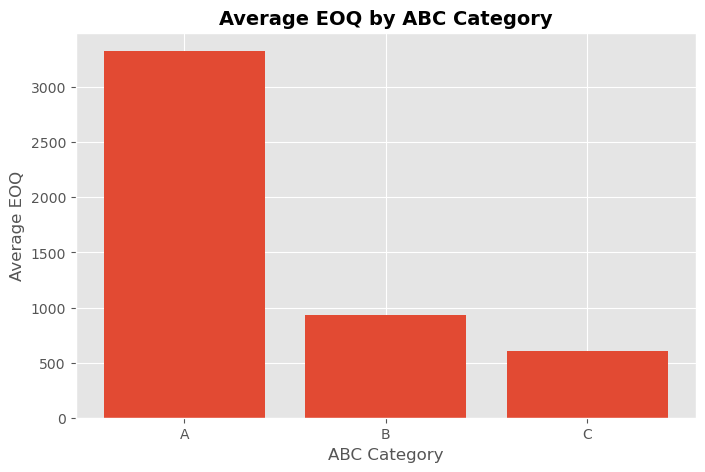

In [25]:
eoq_summary = (
    EOQ.groupby("ABC_Category")
    .agg(
        Avg_EOQ=("EOQ","mean")
    )
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.bar(
    eoq_summary["ABC_Category"],
    eoq_summary["Avg_EOQ"]
)

plt.title(
    "Average EOQ by ABC Category",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("ABC Category")
plt.ylabel("Average EOQ")

plt.show()

### Top 20 EOQ SKUs

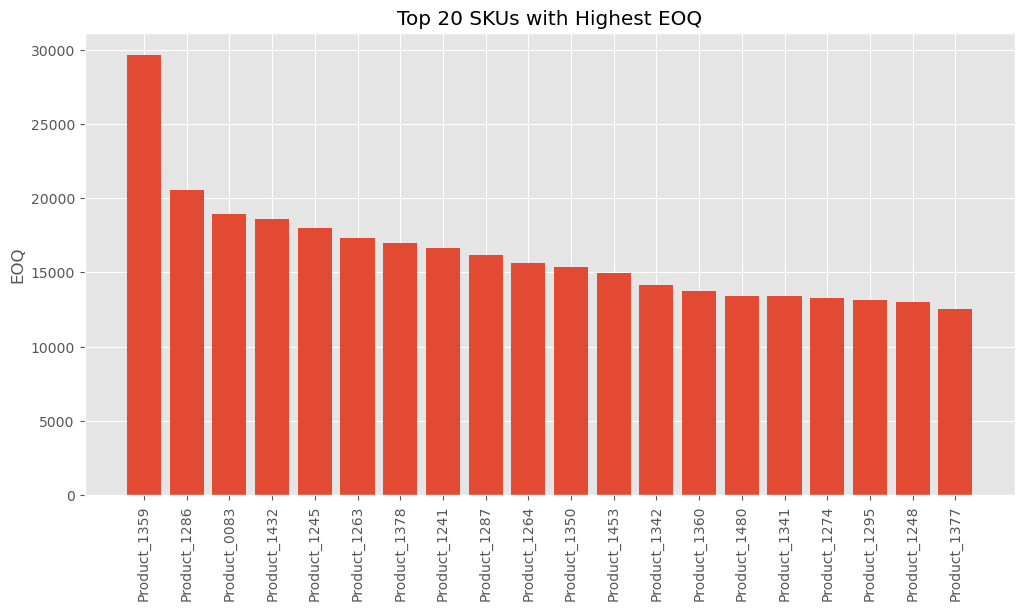

In [26]:
top20_eoq = (
    EOQ.sort_values(
        "EOQ",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,6))

plt.bar(
    top20_eoq["SKU"],
    top20_eoq["EOQ"]
)

plt.xticks(rotation=90)

plt.title(
    "Top 20 SKUs with Highest EOQ"
)

plt.ylabel("EOQ")

plt.show()

---

### Business Interpretation

The EOQ value represents the optimal quantity that should be ordered each time replenishment occurs.

- Higher demand products generally require larger EOQ values.
- Higher ordering costs increase EOQ.
- Higher holding costs reduce EOQ.

The EOQ model minimizes the combined effect of ordering and inventory carrying costs, resulting in a cost-efficient replenishment strategy.

In [27]:
# ==========================================================
# SAVE EOQ DATASET
# ==========================================================

EOQ_Analysis = EOQ.copy()

EOQ_Analysis.to_csv(
    "EOQ_Analysis.csv",
    index=False
)

print("EOQ_Analysis.csv saved successfully.")

EOQ_Analysis.csv saved successfully.


## 9.5 Inventory Control Insights

The previous sections established optimal inventory control parameters including Safety Stock, Reorder Point (ROP), and Economic Order Quantity (EOQ). While these metrics provide quantitative decision support, graphical analysis offers a clearer understanding of inventory behavior and cost dynamics.

This section presents practical inventory control visualizations for the top five high-value products identified through ABC Analysis.

The objectives are:

- To visualize the trade-off between Ordering Cost and Holding Cost.
- To demonstrate how EOQ minimizes total inventory cost.
- To analyze inventory depletion patterns over time.
- To identify reorder triggers and inventory replenishment cycles.
- To evaluate inventory risk using Safety Stock and Reorder Point levels.

The selected products represent the highest inventory value items and therefore have the greatest impact on overall inventory performance.

### 9.5.1 EOQ Cost Trade-Off Curves

Economic Order Quantity (EOQ) determines the optimal order quantity that minimizes the combined inventory costs.

The total inventory cost consists of:

1. Ordering Cost
   - Cost incurred when placing purchase orders.
   - Decreases as order quantity increases.

2. Holding Cost
   - Cost of carrying inventory.
   - Increases as order quantity increases.

3. Total Cost
   - Sum of Ordering Cost and Holding Cost.

The EOQ point represents the quantity at which the total inventory cost reaches its minimum value.

The following figures illustrate the cost trade-off behavior for the top five high-value products.

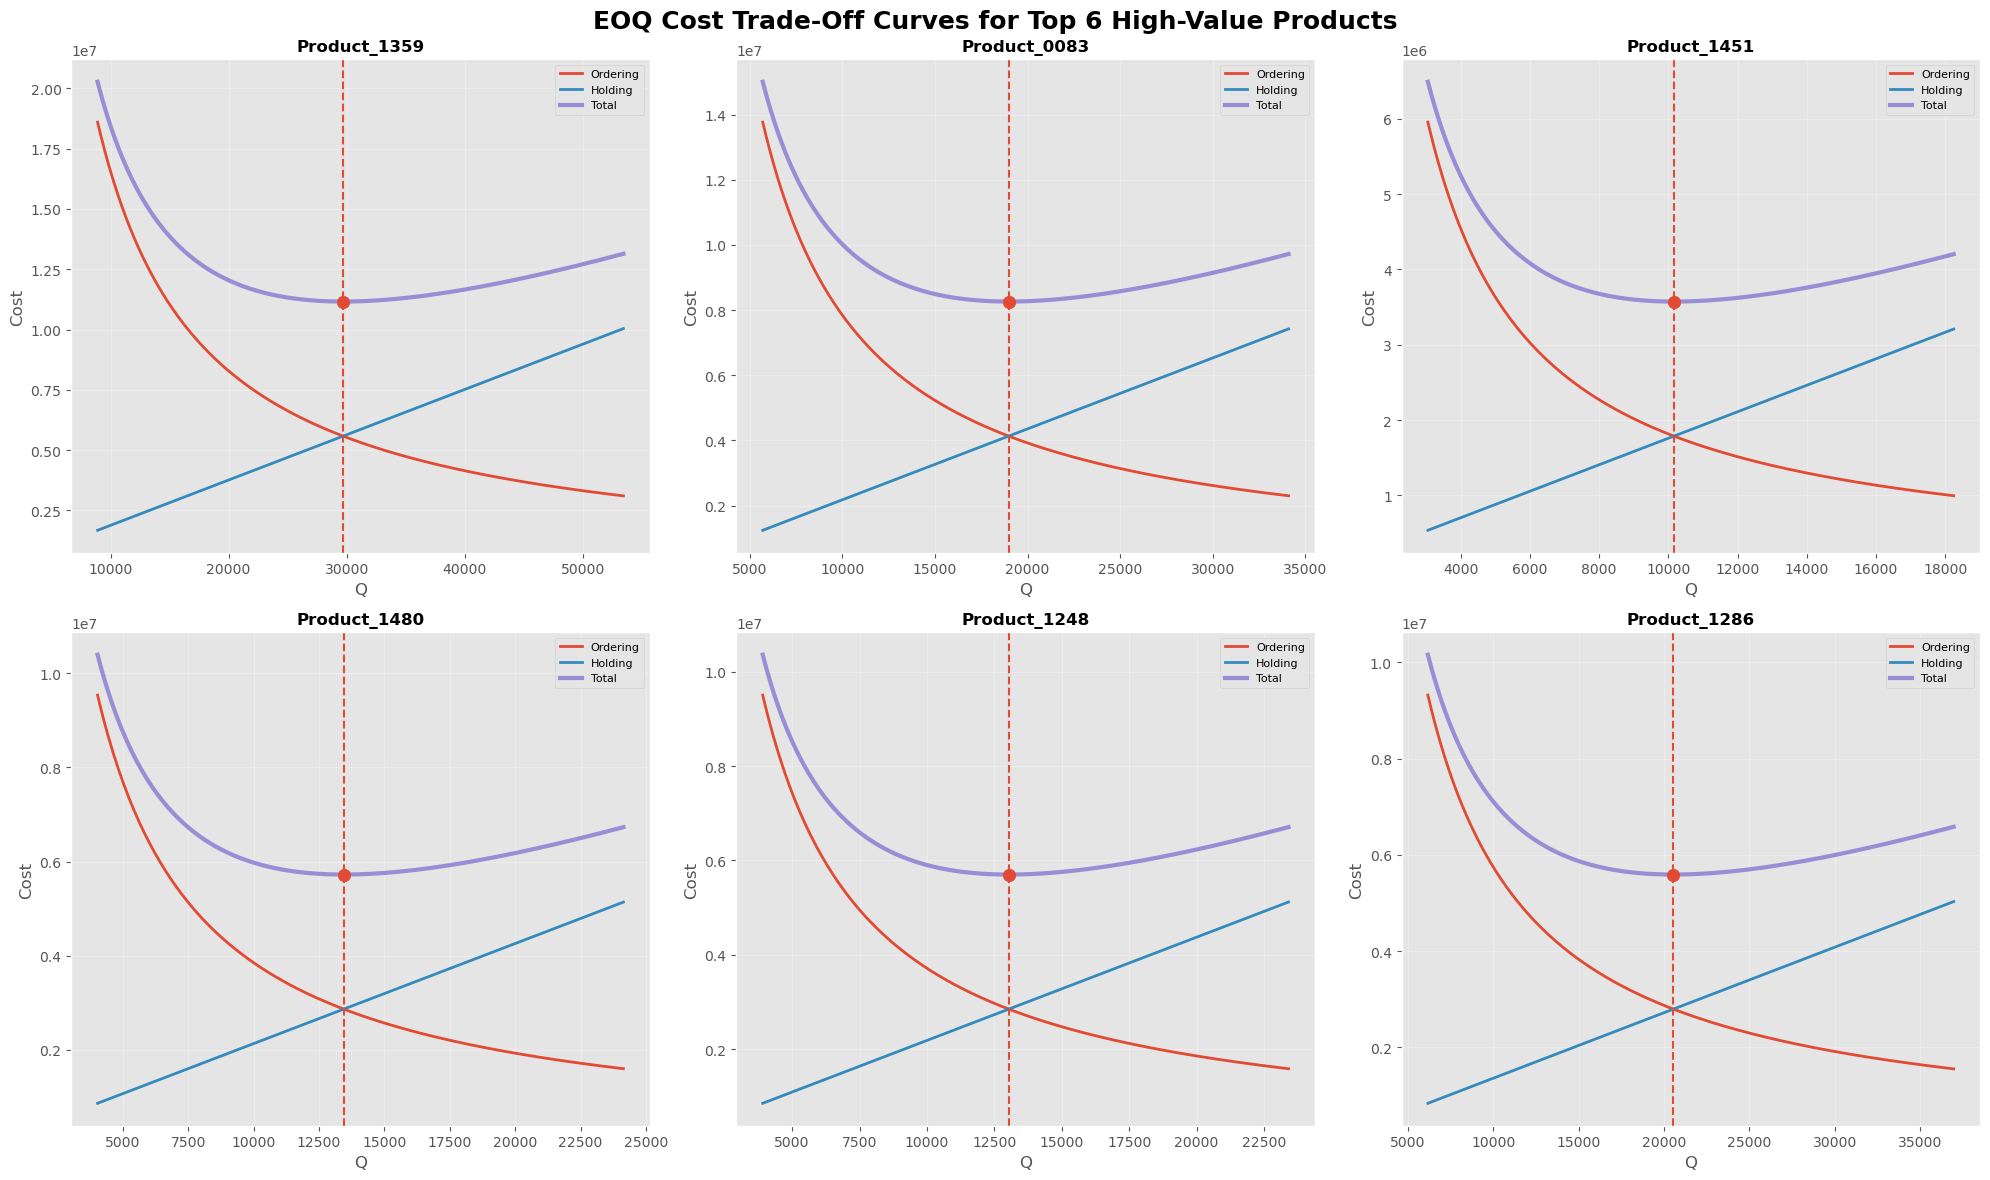

In [28]:
# ==========================================================
# EOQ COST TRADE-OFF CURVES
# TOP 6 PRODUCTS (2 x 3 GRID)
# ==========================================================

Top6 = EOQ.sort_values(
    by="Annual_Consumption_Value",
    ascending=False
).head(6)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(20, 12)
)

axes = axes.flatten()

for i, (_, sku) in enumerate(Top6.iterrows()):

    D = sku["Annual_Demand"]
    S = sku["Ordering_Cost"]
    H = sku["Holding_Cost_Per_Unit_Year"]

    eoq = sku["EOQ"]

    Q = np.arange(
        max(100, int(eoq * 0.3)),
        int(eoq * 1.8),
        100
    )

    ordering_cost = (D / Q) * S

    holding_cost = (Q / 2) * H

    total_cost = ordering_cost + holding_cost

    optimal_cost = (
        (D / eoq) * S
        + (eoq / 2) * H
    )

    ax = axes[i]

    ax.plot(
        Q,
        ordering_cost,
        linewidth=2,
        label="Ordering"
    )

    ax.plot(
        Q,
        holding_cost,
        linewidth=2,
        label="Holding"
    )

    ax.plot(
        Q,
        total_cost,
        linewidth=3,
        label="Total"
    )

    ax.axvline(
        eoq,
        linestyle="--",
        linewidth=1.5
    )

    ax.scatter(
        eoq,
        optimal_cost,
        s=80,
        zorder=5
    )

    ax.set_title(
        sku["SKU"],
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("Q")

    ax.set_ylabel("Cost")

    ax.grid(True, alpha=0.3)

    ax.legend(fontsize=8)

plt.suptitle(
    "EOQ Cost Trade-Off Curves for Top 6 High-Value Products",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### 9.5.2 Inventory Depletion Curves

Inventory Depletion Curves illustrate how inventory levels decrease over time due to customer demand.

The analysis highlights:

- Current Inventory Position
- Daily Consumption Rate
- Reorder Point (ROP)
- Safety Stock Level
- Lead Time Requirements
- Replenishment Trigger Events

When inventory reaches the Reorder Point, a replenishment order is placed. During the supplier lead time, inventory continues to decrease. Safety Stock acts as a protective buffer against demand uncertainty and supply delays.

The following graphs demonstrate inventory behavior for the top five high-value products.

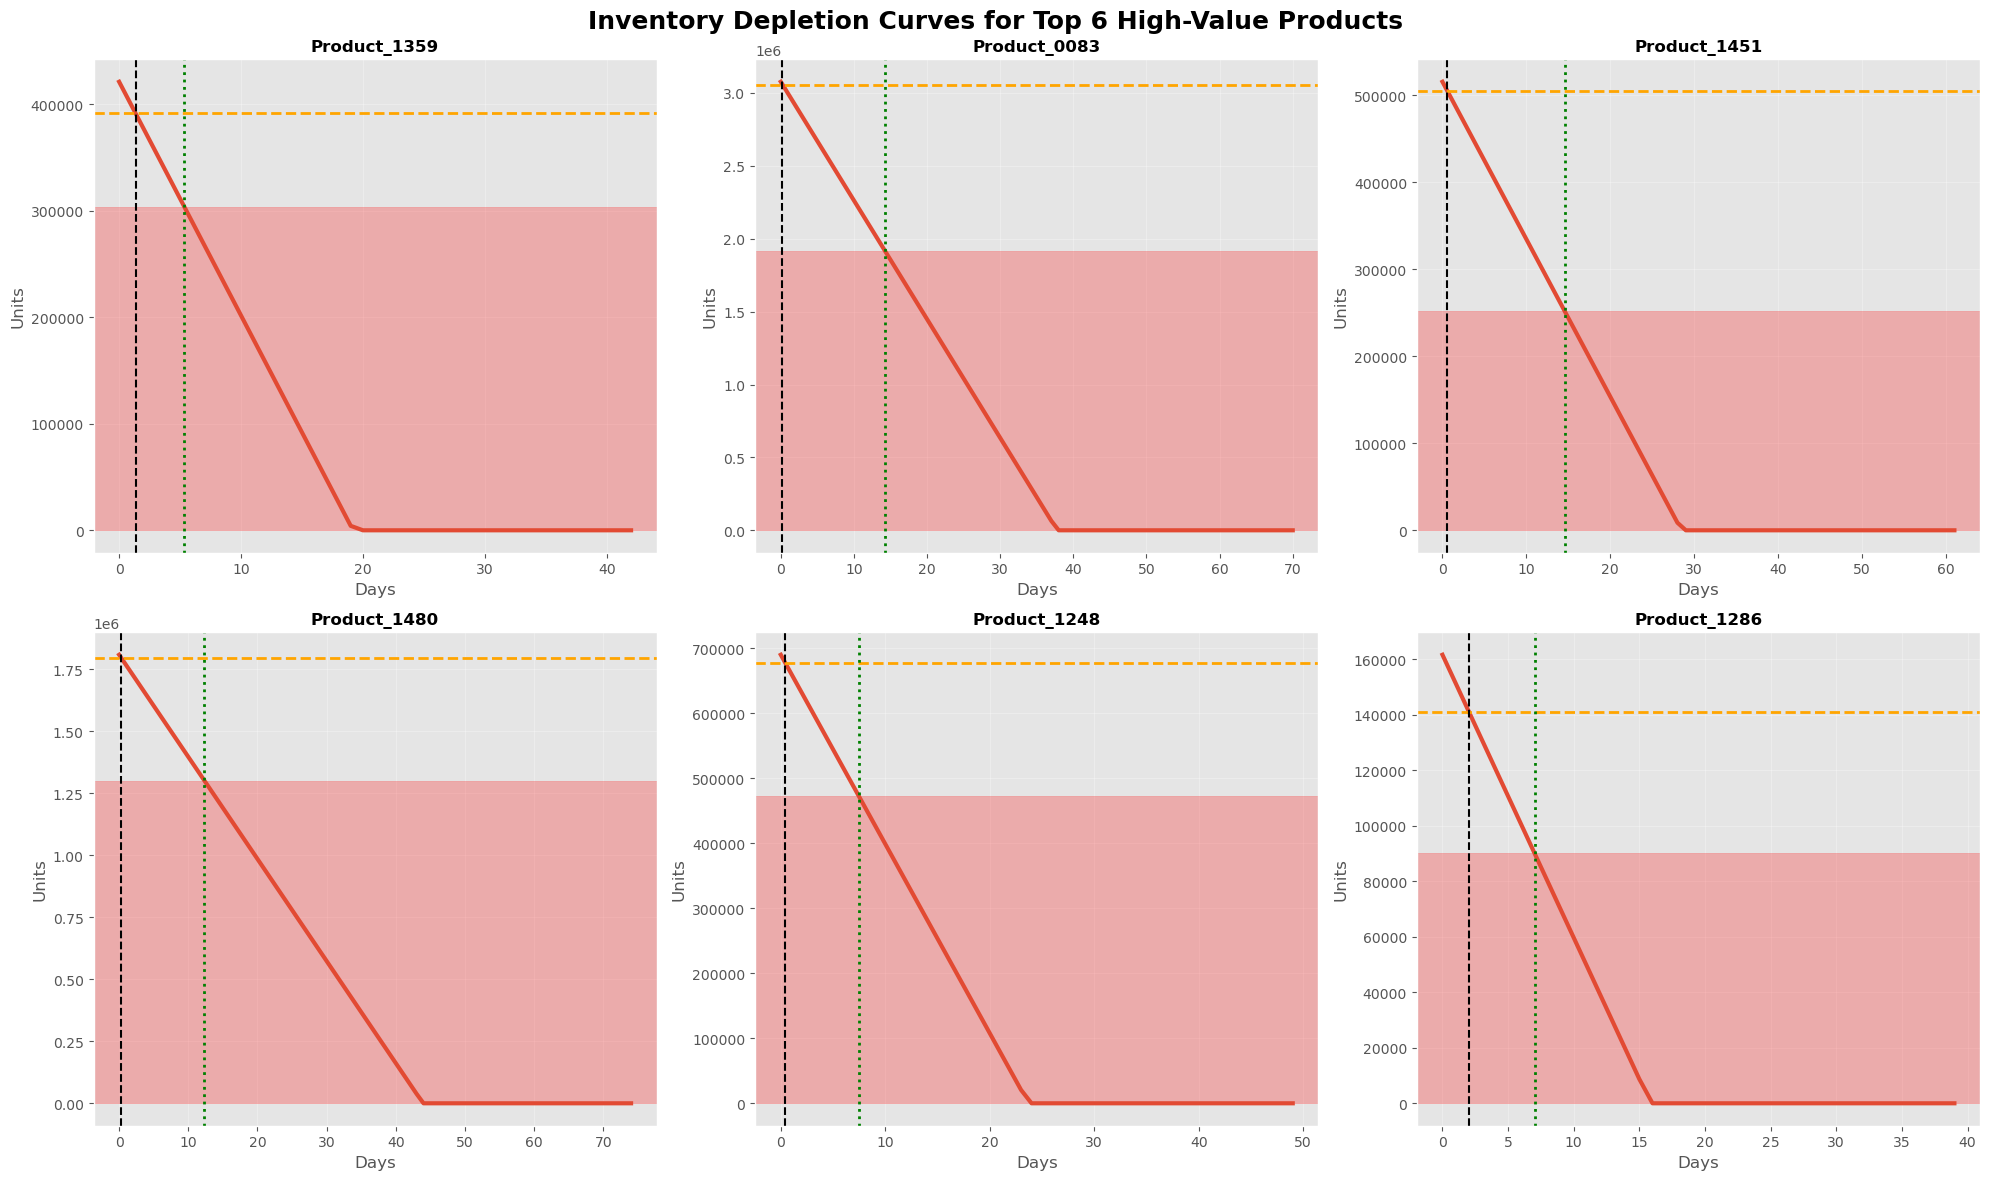

In [29]:
# ==========================================================
# INVENTORY DEPLETION CURVES
# TOP 6 PRODUCTS (2 x 3 GRID)
# ==========================================================

Top6 = EOQ.sort_values(
    by="Annual_Consumption_Value",
    ascending=False
).head(6)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(20, 12)
)

axes = axes.flatten()

for i, (_, sku) in enumerate(Top6.iterrows()):

    daily_demand = sku["Avg_Daily_Demand"]

    lead_time = sku["Lead_Time_Days_y"]

    safety_stock = sku["Safety_Stock"]

    rop = sku["Reorder_Point"]

    eoq = sku["EOQ"]

    initial_inventory = rop + eoq

    days = np.arange(
        0,
        int(
            (initial_inventory / daily_demand)
            + lead_time
            + 20
        )
    )

    inventory = (
        initial_inventory
        - daily_demand * days
    )

    inventory = np.maximum(
        inventory,
        0
    )

    reorder_day = (
        initial_inventory - rop
    ) / daily_demand

    delivery_day = reorder_day + lead_time

    ax = axes[i]

    ax.plot(
        days,
        inventory,
        linewidth=3,
        label="Inventory"
    )

    ax.axhspan(
        0,
        safety_stock,
        alpha=0.25,
        color="red"
    )

    ax.axhline(
        rop,
        linestyle="--",
        color="orange",
        linewidth=2
    )

    ax.axvline(
        reorder_day,
        linestyle="--",
        color="black"
    )

    ax.axvline(
        delivery_day,
        linestyle=":",
        color="green",
        linewidth=2
    )

    ax.set_title(
        sku["SKU"],
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("Days")

    ax.set_ylabel("Units")

    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Inventory Depletion Curves for Top 6 High-Value Products",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [30]:
# ==========================================================
# TOP 6 PRODUCTS - INVENTORY CONTROL SUMMARY
# ==========================================================

Top6_Summary = (
    EOQ
    .sort_values(
        by="Annual_Consumption_Value",
        ascending=False
    )
    [[
        "SKU",
        "Annual_Demand",
        "Safety_Stock",
        "Reorder_Point",
        "EOQ"
    ]]
    .head(6)
    .copy()
)

Top6_Summary = Top6_Summary.round(0)

Top6_Summary

,SKU,Annual_Demand,Safety_Stock,Reorder_Point,EOQ
0,Product_1359,56131008.0,303777.0,391585.0,29685.0
1,Product_0083,29638747.0,1917728.0,3057680.0,18975.0
2,Product_1451,11742166.0,251834.0,505132.0,10162.0
3,Product_1480,11611219.0,1300974.0,1795069.0,13444.0
4,Product_1248,30809329.0,472932.0,676582.0,13035.0
5,Product_1286,13759339.0,90072.0,141033.0,20544.0


### Top 6 Products Inventory Control Summary

To complement the graphical analysis, a summary of key inventory control parameters is presented for the six highest-value products.

The table includes:

- Annual Demand
- Safety Stock
- Reorder Point (ROP)
- Economic Order Quantity (EOQ)

These products represent the most financially significant inventory items and therefore require close monitoring and optimized replenishment strategies. The calculated parameters provide decision support for maintaining service levels while minimizing inventory-related costs.

# 10. Inventory Alerts & Monitoring

The inventory parameters developed in the previous sections provide optimal stock levels for each SKU. However, effective inventory management requires continuous monitoring of current stock positions and timely replenishment decisions.

This section compares current warehouse inventory against calculated Reorder Points (ROP) to identify products requiring immediate replenishment.

The objective is to:

- Identify stockout risks.
- Generate replenishment alerts.
- Prioritize inventory review activities.
- Support proactive inventory control decisions.

Based on the relationship between Current Stock and Reorder Point, each SKU is assigned an inventory status category.

In [31]:
Warehouse_Stock = pd.read_csv('Warehouse_Stock_FINAL.csv')
Warehouse_Stock

,Warehouse,SKU,Current_Stock,Reserved_Stock
0,Whse_A,Product_0001,3363775,2066
1,Whse_A,Product_0020,329512,1771
2,Whse_A,Product_0031,132934,3287
3,Whse_A,Product_0075,413449,6
4,Whse_A,Product_0078,4939,4851
...,...,...,...,...
2764,Whse_S,Product_2165,12136,46
2765,Whse_S,Product_2166,163194,44
2766,Whse_S,Product_2167,3422783,544
2767,Whse_S,Product_2168,6066520,315


In [32]:
# ==========================================================
# INVENTORY ALERT TABLE
# ==========================================================

Inventory_Alerts = Warehouse_Stock.merge(
    EOQ[
        [
            "SKU",
            "Safety_Stock",
            "Reorder_Point",
            "EOQ"
        ]
    ],
    on="SKU",
    how="left"
)

# ----------------------------------------------------------
# Inventory Status
# ----------------------------------------------------------

Inventory_Alerts["Inventory_Status"] = np.select(
    [
        Inventory_Alerts["Current_Stock"]
        <= Inventory_Alerts["Reorder_Point"],

        (
            Inventory_Alerts["Current_Stock"]
            > Inventory_Alerts["Reorder_Point"]
        )
        &
        (
            Inventory_Alerts["Current_Stock"]
            <= 1.2 *
            Inventory_Alerts["Reorder_Point"]
        )
    ],
    [
        "Critical",
        "Warning"
    ],
    default="Healthy"
)

Inventory_Alerts.head()

,Warehouse,SKU,Current_Stock,Reserved_Stock,Safety_Stock,Reorder_Point,EOQ,Inventory_Status
0,Whse_A,Product_0001,3363775,2066,5146.0,8255.0,712.0,Healthy
1,Whse_A,Product_0020,329512,1771,8551.0,12165.0,2605.0,Healthy
2,Whse_A,Product_0031,132934,3287,13605.0,21778.0,2560.0,Healthy
3,Whse_A,Product_0075,413449,6,3.0,20.0,218.0,Healthy
4,Whse_A,Product_0078,4939,4851,13914.0,26776.0,984.0,Critical


In [33]:
Inventory_Alerts["Inventory_Status"].value_counts()

Inventory_Status
Healthy     1488
Critical    1192
Warning       89
Name: count, dtype: int64

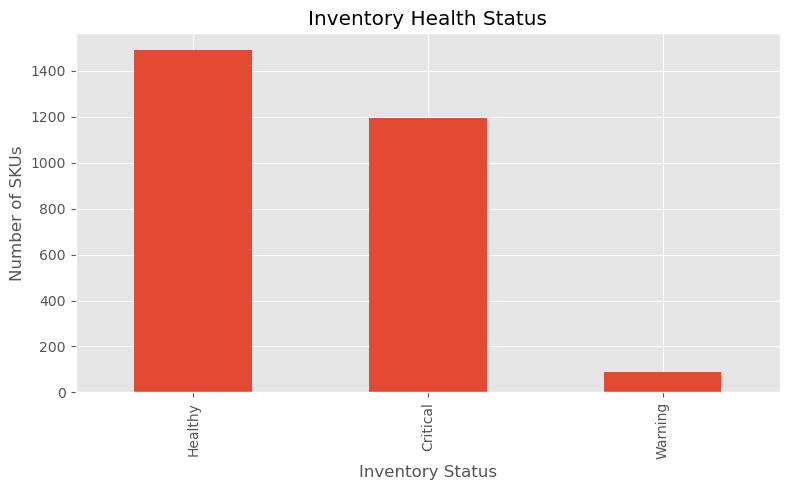

In [34]:
status_counts = (
    Inventory_Alerts["Inventory_Status"]
    .value_counts()
)

status_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Inventory Health Status")
plt.xlabel("Inventory Status")
plt.ylabel("Number of SKUs")

plt.tight_layout()
plt.show()

In [35]:
Critical_SKUs = (
    Inventory_Alerts[
        Inventory_Alerts["Inventory_Status"]
        == "Critical"
    ]
    .sort_values(
        by="Current_Stock"
    )
)

Critical_SKUs.head(20)

,Warehouse,SKU,Current_Stock,Reserved_Stock,Safety_Stock,Reorder_Point,EOQ,Inventory_Status
1972,Whse_J,Product_1756,5,5,4.0,16.0,382.0,Critical
332,Whse_A,Product_1834,13,13,17.0,33.0,883.0,Critical
313,Whse_A,Product_1773,14,6,2.0,15.0,216.0,Critical
153,Whse_A,Product_0825,17,7,6.0,26.0,294.0,Critical
149,Whse_A,Product_0643,17,6,29.0,52.0,1222.0,Critical
495,Whse_C,Product_0611,19,6,13.0,33.0,280.0,Critical
354,Whse_A,Product_1960,19,19,14.0,45.0,989.0,Critical
80,Whse_A,Product_0329,20,19,49.0,101.0,974.0,Critical
325,Whse_A,Product_1808,21,8,10.0,30.0,393.0,Critical
845,Whse_J,Product_0232,22,14,11.0,25.0,1332.0,Critical


In [36]:
Inventory_Alerts["Stock_Gap"] = (
    Inventory_Alerts["Reorder_Point"]
    - Inventory_Alerts["Current_Stock"]
)

Top_Gaps = (
    Inventory_Alerts
    .sort_values(
        by="Stock_Gap",
        ascending=False
    )
)

Top_Gaps.head(20)

,Warehouse,SKU,Current_Stock,Reserved_Stock,Safety_Stock,Reorder_Point,EOQ,Inventory_Status,Stock_Gap
565,Whse_C,Product_1245,970531,970501,3927966.0,8032120.0,18011.0,Critical,7061589.0
2570,Whse_S,Product_1245,1116304,1014873,3927966.0,8032120.0,18011.0,Critical,6915816.0
436,Whse_C,Product_0083,334941,334722,1917728.0,3057680.0,18975.0,Critical,2722739.0
747,Whse_J,Product_0083,531046,529946,1917728.0,3057680.0,18975.0,Critical,2526634.0
2309,Whse_S,Product_0083,585577,499528,1917728.0,3057680.0,18975.0,Critical,2472103.0
555,Whse_C,Product_1166,592063,591949,1199251.0,2288315.0,8786.0,Critical,1696252.0
603,Whse_C,Product_1480,149597,149330,1300974.0,1795069.0,13444.0,Critical,1645472.0
1779,Whse_J,Product_1480,177427,167994,1300974.0,1795069.0,13444.0,Critical,1617642.0
2619,Whse_S,Product_1480,316407,165147,1300974.0,1795069.0,13444.0,Critical,1478662.0
567,Whse_C,Product_1263,192258,192223,967615.0,1579592.0,17343.0,Critical,1387334.0


### Inventory Monitoring Results

The inventory alert system classified all SKUs into three operational categories:

- Critical: Current stock is at or below the Reorder Point and requires immediate replenishment.
- Warning: Current stock is approaching the Reorder Point and should be monitored closely.
- Healthy: Inventory levels are sufficient and no immediate action is required.

This monitoring framework enables inventory managers to prioritize replenishment decisions and reduce stockout risk across the supply chain network.

In [37]:
Top_Gaps.to_csv(
    "Inventory_Status_Analysis.csv",
    index=False
)

print(
    "Inventory_Status_Analysis.csv saved successfully."
)

Inventory_Status_Analysis.csv saved successfully.


# 11. Kraljic Matrix Analysis

The Kraljic Matrix is a strategic procurement framework used to classify inventory items based on two dimensions:

1. Supply Risk
2. Profit Impact

Supply Risk was derived using supplier reliability data. Lower supplier reliability indicates higher supply risk.

Profit Impact was represented using Annual Consumption Value obtained from the ABC Analysis.

In this study:

- Annual Consumption Value is used as a measure of Profit Impact.
- Supplier Reliability is used to estimate Supply Risk.

Supply Risk is calculated as:

Supply Risk = 100 − Supplier Reliability

A normalized scoring approach was used to position each SKU within the Kraljic Matrix.

The resulting classification supports procurement planning, supplier management, inventory control, and risk mitigation strategies.

Based on the quadrant classification, inventory policies were assigned to each SKU:

- Strategic Items → Long-Term Supplier Partnerships
- Leverage Items → Bulk Procurement and Cost Negotiation
- Bottleneck Items → Higher Safety Stock and Risk Monitoring
- Non-Critical Items → Automated Replenishment and Simplified Ordering

This analysis converts inventory planning from a purely operational activity into a strategic supply chain decision-making framework.

## 11.1 Prepare Kraljic Dataset

In [38]:
Kraljic = EOQ.copy()

# Supply Risk
Kraljic["Supply_Risk"] = (
    100 - Kraljic["Supplier_Reliability"]
)

# Profit Impact
Kraljic["Profit_Impact"] = (
    Kraljic["Annual_Consumption_Value"]
)

Kraljic.head()

,SKU,Annual_Demand,Unit_Cost_x,Annual_Consumption_Value,ABC_Category,Avg_Daily_Demand,Demand_Std_Dev,Supplier_ID,Lead_Time_Days_x,Supplier_Reliability,...,Safety_Stock,Reorder_Point,Product_Category,Unit_Cost_y,Lead_Time_Days_y,Ordering_Cost,Holding_Cost_Per_Unit_Year,EOQ,Supply_Risk,Profit_Impact
0,Product_1359,5.613101e+07,0.61,3.423992e+07,A,21951.900077,65188.054362,SUP_0001,4,99.00,...,303777.0,391585.0,Category_019,0.61,4,2951,375.96,29685.0,1.00,3.423992e+07
1,Product_0083,2.963875e+07,1.15,3.408456e+07,A,81425.128498,219971.775068,SUP_0002,14,67.54,...,1917728.0,3057680.0,Category_019,1.15,14,2644,435.32,18975.0,32.46,3.408456e+07
2,Product_1451,1.174217e+07,2.89,3.393486e+07,A,18092.705046,28886.460936,SUP_0009,14,41.25,...,251834.0,505132.0,Category_019,2.89,14,1546,351.61,10162.0,58.75,3.393486e+07
3,Product_1480,1.161122e+07,2.92,3.390476e+07,A,41174.537083,161184.023699,SUP_0014,12,44.27,...,1300974.0,1795069.0,Category_019,2.92,12,3313,425.67,13444.0,55.73,3.390476e+07
4,Product_1248,3.080933e+07,1.10,3.389026e+07,A,29092.850967,76717.361394,SUP_0003,7,79.29,...,472932.0,676582.0,Category_019,1.10,7,1206,437.39,13035.0,20.71,3.389026e+07


## 11.2 Normalize Scores

In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

Kraljic["Supply_Risk_Score"] = scaler.fit_transform(
    Kraljic[["Supply_Risk"]]
)

Kraljic["Profit_Impact_Score"] = scaler.fit_transform(
    Kraljic[["Profit_Impact"]]
)

## 11.3 Create Quadrants

In [40]:
def classify_kraljic(row):

    if (
        row["Profit_Impact_Score"] >= 0.5
        and
        row["Supply_Risk_Score"] >= 0.5
    ):
        return "Strategic"

    elif (
        row["Profit_Impact_Score"] >= 0.5
        and
        row["Supply_Risk_Score"] < 0.5
    ):
        return "Leverage"

    elif (
        row["Profit_Impact_Score"] < 0.5
        and
        row["Supply_Risk_Score"] >= 0.5
    ):
        return "Bottleneck"

    else:
        return "Non-Critical"


Kraljic["Kraljic_Category"] = (
    Kraljic.apply(
        classify_kraljic,
        axis=1
    )
)

Kraljic["Kraljic_Category"].value_counts()

Kraljic_Category
Non-Critical    1218
Leverage         409
Bottleneck       405
Strategic         85
Name: count, dtype: int64

## 11.4 Kraljic Matrix Plot

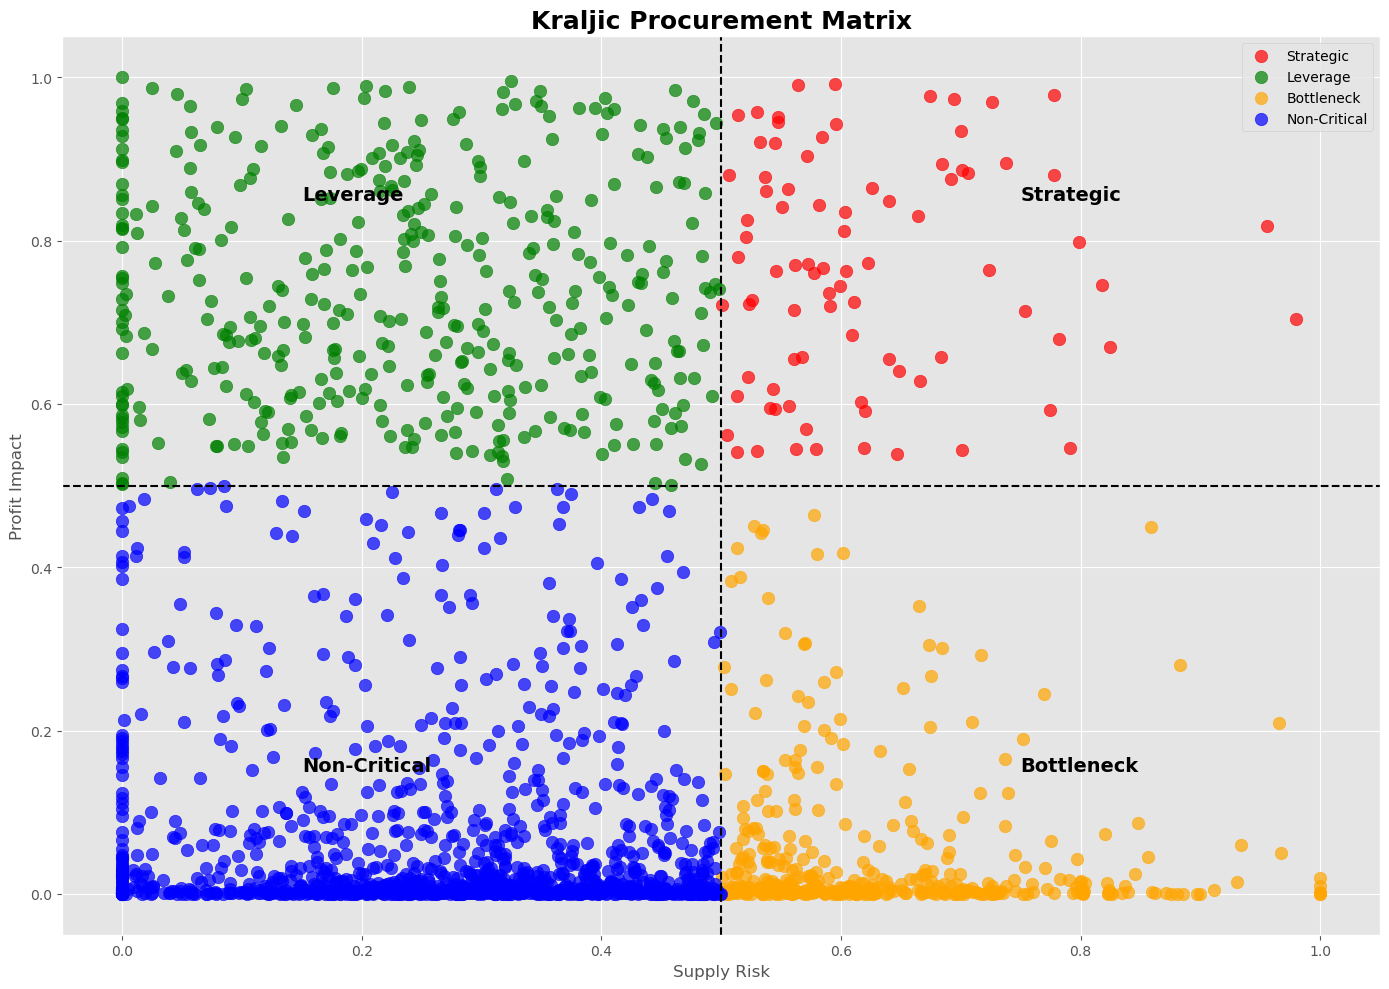

In [41]:
plt.style.use("ggplot")

fig, ax = plt.subplots(
    figsize=(14,10)
)

colors = {
    "Strategic":"red",
    "Leverage":"green",
    "Bottleneck":"orange",
    "Non-Critical":"blue"
}

for category in colors.keys():

    temp = Kraljic[
        Kraljic["Kraljic_Category"] == category
    ]

    ax.scatter(
        temp["Supply_Risk_Score"],
        temp["Profit_Impact_Score"],
        s=80,
        alpha=0.7,
        label=category,
        color=colors[category]
    )

# quadrant lines
ax.axvline(
    0.5,
    linestyle="--",
    color="black"
)

ax.axhline(
    0.5,
    linestyle="--",
    color="black"
)

# labels
ax.text(
    0.75,
    0.85,
    "Strategic",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    0.75,
    0.15,
    "Bottleneck",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    0.15,
    0.85,
    "Leverage",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    0.15,
    0.15,
    "Non-Critical",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "Kraljic Procurement Matrix",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel(
    "Supply Risk"
)

ax.set_ylabel(
    "Profit Impact"
)

ax.legend()

plt.tight_layout()
plt.show()

## 11.5 Top Strategic Products

In [42]:
Strategic_Items = (
    Kraljic[
        Kraljic["Kraljic_Category"] == "Strategic"
    ]
    .sort_values(
        by="Annual_Consumption_Value",
        ascending=False
    )
)

Strategic_Items[
    [
        "SKU",
        "Annual_Consumption_Value",
        "Supplier_Reliability",
        "Kraljic_Category"
    ]
].head(20)

,SKU,Annual_Consumption_Value,Supplier_Reliability,Kraljic_Category
2,Product_1451,3.393486e+07,41.25,Strategic
3,Product_1480,3.390476e+07,44.27,Strategic
14,Product_1166,3.348375e+07,23.59,Strategic
15,Product_1152,3.344713e+07,33.59,Strategic
19,Product_1570,3.333154e+07,31.63,Strategic
22,Product_0931,3.321366e+07,28.56,Strategic
34,Product_1393,3.276837e+07,47.64,Strategic
37,Product_1377,3.266858e+07,49.14,Strategic
39,Product_1361,3.256234e+07,45.89,Strategic
44,Product_1150,3.237953e+07,45.88,Strategic


## 11.6 Inventory Policy Mapping

In [43]:
policy_map = {

    "Strategic":
    "Long-Term Supplier Partnership",

    "Leverage":
    "Bulk Procurement & Cost Negotiation",

    "Bottleneck":
    "Maintain Higher Safety Stock",

    "Non-Critical":
    "Automated Replenishment"
}

Kraljic["Inventory_Policy"] = (
    Kraljic["Kraljic_Category"]
    .map(policy_map)
)

Kraljic[
    [
        "SKU",
        "Kraljic_Category",
        "Inventory_Policy"
    ]
]

,SKU,Kraljic_Category,Inventory_Policy
0,Product_1359,Leverage,Bulk Procurement & Cost Negotiation
1,Product_0083,Leverage,Bulk Procurement & Cost Negotiation
2,Product_1451,Strategic,Long-Term Supplier Partnership
3,Product_1480,Strategic,Long-Term Supplier Partnership
4,Product_1248,Leverage,Bulk Procurement & Cost Negotiation
...,...,...,...
2112,Product_0592,Bottleneck,Maintain Higher Safety Stock
2113,Product_1631,Non-Critical,Automated Replenishment
2114,Product_0948,Bottleneck,Maintain Higher Safety Stock
2115,Product_1433,Non-Critical,Automated Replenishment


## 11.7 Policy Summary

In [44]:
Policy_Summary = (
    Kraljic.groupby(
        [
            "Kraljic_Category",
            "Inventory_Policy"
        ]
    )
    .size()
    .reset_index(
        name="SKU_Count"
    )
)

Policy_Summary

,Kraljic_Category,Inventory_Policy,SKU_Count
0,Bottleneck,Maintain Higher Safety Stock,405
1,Leverage,Bulk Procurement & Cost Negotiation,409
2,Non-Critical,Automated Replenishment,1218
3,Strategic,Long-Term Supplier Partnership,85


In [45]:
Kraljic.to_csv(
    "Kraljic_Matrix_Analysis.csv",
    index=False
)

print(
    "Kraljic_Matrix_Analysis.csv saved successfully."
)

Kraljic_Matrix_Analysis.csv saved successfully.


# 12. Inventory Policy Recommendations

The previous analyses provided inventory classifications, replenishment parameters, and procurement risk assessments for all SKUs.

To convert analytical insights into actionable business decisions, inventory control policies were assigned based on the combined results of:

- ABC Analysis
- Kraljic Matrix Analysis

The objective is to ensure that inventory resources, monitoring efforts, and procurement strategies are aligned with the operational importance and supply risk associated with each product.

The resulting policy framework provides differentiated inventory control strategies for various categories of products.

## 12.1 Inventory Policy Engine

In [46]:
Inventory_Policies = Kraljic.copy()

def assign_policy(row):

    abc = row["ABC_Category"]
    kraljic = row["Kraljic_Category"]

    if abc == "A" and kraljic == "Strategic":
        return "Continuous Review + Long-Term Contract"

    elif abc == "A" and kraljic == "Leverage":
        return "EOQ Ordering + Weekly Review"

    elif abc == "A" and kraljic == "Bottleneck":
        return "High Safety Stock + Backup Supplier"

    elif abc == "A":
        return "Weekly Monitoring"

    elif abc == "B" and kraljic == "Strategic":
        return "Periodic Review"

    elif abc == "B" and kraljic == "Leverage":
        return "EOQ-Based Replenishment"

    elif abc == "B" and kraljic == "Bottleneck":
        return "Additional Buffer Stock"

    elif abc == "B":
        return "Monthly Review"

    elif abc == "C" and kraljic == "Strategic":
        return "Supplier Development"

    elif abc == "C" and kraljic == "Leverage":
        return "Bulk Ordering"

    elif abc == "C" and kraljic == "Bottleneck":
        return "Backup Inventory"

    else:
        return "Simple Replenishment"


Inventory_Policies["Recommended_Policy"] = (
    Inventory_Policies.apply(
        assign_policy,
        axis=1
    )
)

Inventory_Policies.head()

,SKU,Annual_Demand,Unit_Cost_x,Annual_Consumption_Value,ABC_Category,Avg_Daily_Demand,Demand_Std_Dev,Supplier_ID,Lead_Time_Days_x,Supplier_Reliability,...,Ordering_Cost,Holding_Cost_Per_Unit_Year,EOQ,Supply_Risk,Profit_Impact,Supply_Risk_Score,Profit_Impact_Score,Kraljic_Category,Inventory_Policy,Recommended_Policy
0,Product_1359,5.613101e+07,0.61,3.423992e+07,A,21951.900077,65188.054362,SUP_0001,4,99.00,...,2951,375.96,29685.0,1.00,3.423992e+07,0.000000,1.000000,Leverage,Bulk Procurement & Cost Negotiation,EOQ Ordering + Weekly Review
1,Product_0083,2.963875e+07,1.15,3.408456e+07,A,81425.128498,219971.775068,SUP_0002,14,67.54,...,2644,435.32,18975.0,32.46,3.408456e+07,0.324330,0.995463,Leverage,Bulk Procurement & Cost Negotiation,EOQ Ordering + Weekly Review
2,Product_1451,1.174217e+07,2.89,3.393486e+07,A,18092.705046,28886.460936,SUP_0009,14,41.25,...,1546,351.61,10162.0,58.75,3.393486e+07,0.595361,0.991091,Strategic,Long-Term Supplier Partnership,Continuous Review + Long-Term Contract
3,Product_1480,1.161122e+07,2.92,3.390476e+07,A,41174.537083,161184.023699,SUP_0014,12,44.27,...,3313,425.67,13444.0,55.73,3.390476e+07,0.564227,0.990212,Strategic,Long-Term Supplier Partnership,Continuous Review + Long-Term Contract
4,Product_1248,3.080933e+07,1.10,3.389026e+07,A,29092.850967,76717.361394,SUP_0003,7,79.29,...,1206,437.39,13035.0,20.71,3.389026e+07,0.203196,0.989788,Leverage,Bulk Procurement & Cost Negotiation,EOQ Ordering + Weekly Review


## 12.2 Policy Summary

In [47]:
Policy_Summary = (
    Inventory_Policies
    .groupby(
        "Recommended_Policy"
    )
    .size()
    .reset_index(
        name="SKU_Count"
    )
    .sort_values(
        by="SKU_Count",
        ascending=False
    )
)

Policy_Summary

,Recommended_Policy,SKU_Count
5,Simple Replenishment,990
3,EOQ Ordering + Weekly Review,409
1,Backup Inventory,344
4,Monthly Review,217
2,Continuous Review + Long-Term Contract,85
0,Additional Buffer Stock,61
6,Weekly Monitoring,11


## 12.3 Policy Distribution Chart

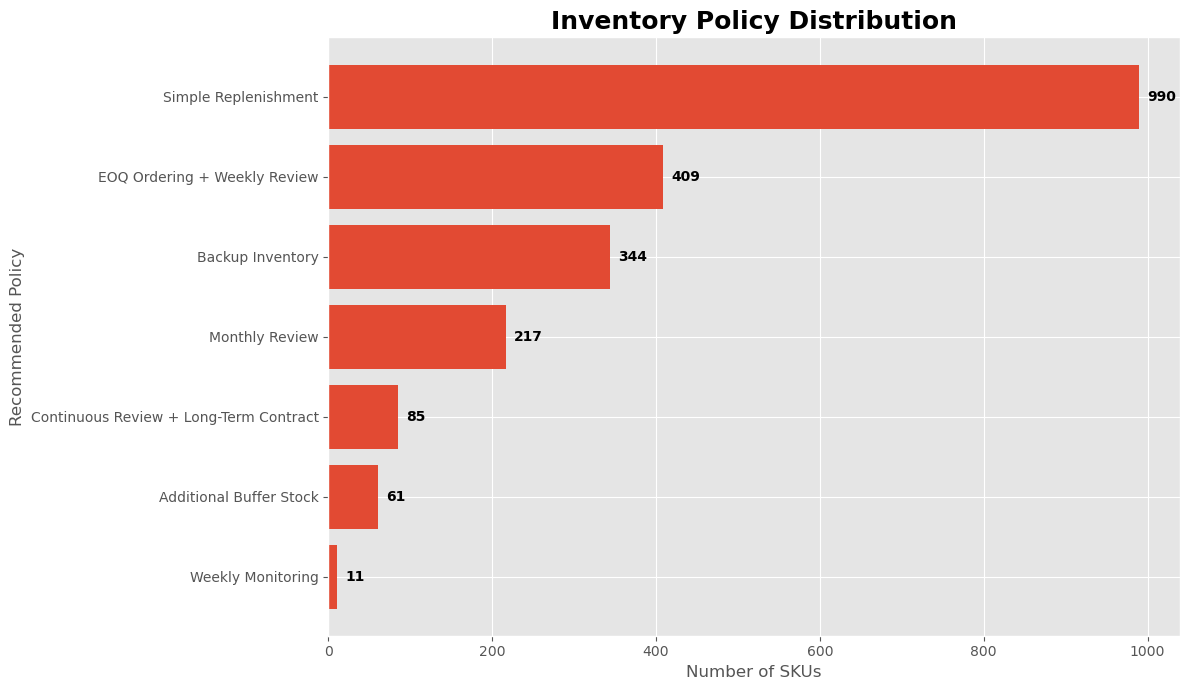

In [48]:
# ==========================================================
# POLICY DISTRIBUTION
# ==========================================================

Policy_Summary = Policy_Summary.sort_values(
    by="SKU_Count",
    ascending=True
)

plt.style.use("ggplot")

fig, ax = plt.subplots(
    figsize=(12,7)
)

bars = ax.barh(
    Policy_Summary["Recommended_Policy"],
    Policy_Summary["SKU_Count"]
)

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 10,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontweight="bold"
    )

ax.set_title(
    "Inventory Policy Distribution",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel(
    "Number of SKUs"
)

ax.set_ylabel(
    "Recommended Policy"
)

plt.tight_layout()

plt.show()

In [49]:
Inventory_Policies.to_csv(
    "Inventory_Policies.csv",
    index=False
)

print(
    "Inventory_Policies.csv saved successfully."
)

Inventory_Policies.csv saved successfully.


<h1 align="center"><i><b>THE END</b></i></h1>